# 이민지·이석훈 (2025) 「VAE 기반 데이터 불균형 개선을 통한 치매 조기 탐지 기법」 — 실험 A·B·C 단일 노트북

*Journal of KIIT* 23(7), pp.1–12 · [DOI 10.14801/jkiit.2025.23.7.1](https://doi.org/10.14801/jkiit.2025.23.7.1)

**이 노트북은 학습 코드 전체가 셀 안에 있는 독립 구현이다.** 저장소의 다른 파일을
임포트하지 않으며, Colab에서 이 파일 하나로 데이터 적재부터 시각화까지 실행된다.
데이터는 `내 드라이브/Data/`(`1.Training`·`2.Validation`)에서 읽는다.

| 실험 | 내용 | 분할 | 하이퍼파라미터 | 주 평가 단위 |
| --- | --- | --- | --- | --- |
| **A** | 원본 논문 재현 — 행 단위 8:1:1, 전처리 전체-적합까지 논문 절차 그대로 | 행 단위 | 논문 고정 | 기록 (피험자 집계 병행) |
| **B** | 다른 조건은 A와 동일, **분할만 피험자 단위**로 변경 | 피험자 층화 3-fold | 논문 고정 | **피험자** |
| **C** | 피험자 단위 분할 위의 **Nested CV** — 분류기·증강을 inner CV가 선택 | outer 3 × inner 3 | **inner CV 선택** | **피험자** |

**논문이 보고한 값은 그대로 쓰고, 미보고 항목은 가정값을 쓴다** (해당 셀에 주석으로 명시).
논문 내부 충돌은 다음과 같이 정리한다:

- 이상치: §4.2 Isolation Forest ↔ §5.1 "상·하위 10%" 충돌. 46개 변수에 §5.1 해석을
  적용하면 Dem이 6행만 남아 8:1:1 분할이 불가능하므로, 잔존 행 수(10,964)가 §5.1
  보고값과 정합하는 **Isolation Forest(contamination=0.1)** 를 쓴다.
- VAE latent 차원: 본문 500 ↔ 그림 2의 50 → **본문 500**을 쓴다.
- 합성 Dem 행 수: 표 5에서 산술 유도된 **4,000행** (train Dem 412 → 4,412).

**실행**: 런타임 T4 GPU 권장 → "모두 실행". 예상 소요: A ≈ 수 분 · B ≈ 10–20분 ·
**C는 수 시간**. 산출물(csv/json)은 `내 드라이브/reproduction_lee_lee_2025_vae_notebook/`
아래 타임스탬프 폴더에 저장된다. `QUICK_TEST = True`로 바꾸면 epoch·후보를 크게 줄여
배선만 몇 분 안에 확인할 수 있다(그 결과는 인용 금지).


## 1. 설정

In [ ]:
# ── 1. 설정 ──────────────────────────────────────────────────────────────────
SEED = 42                  # 논문 미보고 → 가정
QUICK_TEST = False         # True: epoch·후보를 크게 줄여 배선만 확인 (결과 인용 금지)
MYDRIVE_DATA_DIR = "Data"  # 내 드라이브 안의 데이터 폴더명 (mydrive/Data)

import os
import subprocess
import sys
import time
from pathlib import Path

if sys.platform == "darwin":
    # 로컬 macOS: torch와 xgboost가 각자 OpenMP 런타임(libomp)을 로드해 두 라이브러리를
    # 한 프로세스에서 쓰면 segfault가 난다. 라이브러리 import 전에 설정해야 하며,
    # Colab(Linux)에는 영향이 없다.
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive") / MYDRIVE_DATA_DIR
    OUT_DIR = (Path("/content/drive/MyDrive/reproduction_lee_lee_2025_vae_notebook")
               / time.strftime("%Y%m%d_%H%M%S"))
else:  # 로컬: 저장소 안에서 열었으면 Data/를 위로 올라가며 찾는다
    _here = Path.cwd().resolve()
    _root = next((p for p in (_here, *_here.parents)
                  if (p / "Data" / "1.Training").exists()), None)
    assert _root is not None, "Data/를 찾지 못했다. 저장소 안에서 실행하거나 DATA_DIR을 지정하라."
    DATA_DIR = _root / "Data"
    OUT_DIR = _here / "outputs" / time.strftime("%Y%m%d_%H%M%S")

if not (DATA_DIR / "1.Training").exists():
    raise FileNotFoundError(
        f"{DATA_DIR} 아래에 1.Training이 없다. 내 드라이브에 "
        f"'{MYDRIVE_DATA_DIR}/1.Training', '{MYDRIVE_DATA_DIR}/2.Validation'이 있는지 "
        "확인하고, 폴더명이 다르면 MYDRIVE_DATA_DIR을 고쳐라.")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR :", DATA_DIR)
print("OUT_DIR  :", OUT_DIR)

# 의존성: Colab 기본 환경에 없는 것만 설치
try:
    import pytorch_tabnet  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytorch-tabnet"], check=True)

# ── 논문 보고값(고정)과 미보고 항목의 가정값 ─────────────────────────────────
CLASS_ORDER = ["CN", "MCI", "Dem"]   # 0=CN, 1=MCI, 2=Dem
N_CLASSES = 3

ISO_CONTAMINATION = 0.1   # §4.2 Isolation Forest — 잔존 10,964행이 §5.1 보고값과 정합
LATENT_DIM = 500          # §5.1 본문 (그림 2는 50 — 본문 우선)
VAE_HIDDEN = (512, 256)   # §5.1
VAE_DROPOUT = 0.3         # §5.1
VAE_LR = 1e-4             # §5.1
N_SYNTHETIC_A = 4000      # 표 5 유도 (Dem train 4,412 = 실제 412 + 합성 4,000)
SYN_RATIO_B = 9.71        # 실험 B: fold별 실제 train Dem 행 수 × 9.71 (표 5와 같은 배율)

MODELS = ["xgboost", "dnn", "tabnet", "wide_deep"]

# 미보고 → 가정 (epoch·batch·early stopping)
VAE_EPOCHS = 8 if QUICK_TEST else 300
CLF_EPOCHS = 6 if QUICK_TEST else 200
TABNET_EPOCHS = 5 if QUICK_TEST else 200
XGB_TREES = 30 if QUICK_TEST else 100
ES_PATIENCE = 3 if QUICK_TEST else 20
N_BOOT = 200 if QUICK_TEST else 2000
if QUICK_TEST:
    N_SYNTHETIC_A = 400
    print("⚠️ QUICK_TEST 모드 — 배선 확인용. 결과를 인용하지 마라.")


Mounted at /content/drive
DATA_DIR : /content/drive/MyDrive/Data
OUT_DIR  : /content/drive/MyDrive/reproduction_lee_lee_2025_vae_notebook/20260813_020619


## 2. 라이브러리와 재현성

In [ ]:
# ── 2. 라이브러리와 재현성 ───────────────────────────────────────────────────
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_recall_fscore_support, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__)


device: cuda | torch 2.11.0+cu128


## 3. 데이터 적재 — 논문 코호트 재구성

AI-Hub Training + Validation 합본이 논문 표 3과 정확히 일치한다
(피험자 174명: CN 111 / MCI 51 / Dem 12, 기록 12,183행: 7,737 / 3,661 / 785).
activity·sleep 파일에 날짜 컬럼이 없으므로 두 파일의 `EMAIL`이 행 단위로 동일한
순서임을 확인한 뒤 위치 기반으로 결합한다. 변수는 논문 표 1(활동 22개)·표 2(수면
24개)의 46개를 그대로 쓴다.


In [ ]:
# ── 3. 데이터 적재 ───────────────────────────────────────────────────────────
ACTIVITY_FEATURES = [
    "activity_average_met", "activity_cal_active", "activity_cal_total",
    "activity_daily_movement", "activity_high", "activity_inactive", "activity_low",
    "activity_medium", "activity_met_min_high", "activity_met_min_inactive",
    "activity_met_min_low", "activity_met_min_medium", "activity_rest",
    "activity_score", "activity_score_meet_daily_targets",
    "activity_score_move_every_hour", "activity_score_recovery_time",
    "activity_score_stay_active", "activity_score_training_frequency",
    "activity_score_training_volume", "activity_steps", "activity_total",
]  # 논문 표 1
SLEEP_FEATURES = [
    "sleep_awake", "sleep_breath_average", "sleep_deep", "sleep_duration",
    "sleep_efficiency", "sleep_hr_average", "sleep_hr_lowest", "sleep_light",
    "sleep_midpoint_at_delta", "sleep_midpoint_time", "sleep_onset_latency",
    "sleep_rem", "sleep_restless", "sleep_rmssd", "sleep_score",
    "sleep_score_alignment", "sleep_score_deep", "sleep_score_disturbances",
    "sleep_score_efficiency", "sleep_score_latency", "sleep_score_rem",
    "sleep_score_total", "sleep_temperature_delta", "sleep_temperature_deviation",
]  # 논문 표 2
FEATURES = ACTIVITY_FEATURES + SLEEP_FEATURES
assert len(FEATURES) == 46

_PARTS = {
    "training": ("1.Training/SourceData/1.Gait/train_activity.csv",
                 "1.Training/SourceData/2.Sleep/train_sleep.csv",
                 "1.Training/LabelingData/1.Gait/training_label.csv"),
    "validation": ("2.Validation/SourceData/1.Gait/val_activity.csv",
                   "2.Validation/SourceData/2.Sleep/val_sleep.csv",
                   "2.Validation/LabelingData/1.Gait/val_label.csv"),
}

_acts, _slps, _labs = [], [], []
for _name, (_a, _s, _l) in _PARTS.items():
    a = pd.read_csv(DATA_DIR / _a)
    s = pd.read_csv(DATA_DIR / _s)
    assert len(a) == len(s), f"[{_name}] activity와 sleep의 행 수가 다르다"
    # 날짜가 없으므로 위치 결합만 가능 — EMAIL 순서가 동일함을 매번 확인한다
    assert (a["EMAIL"].values == s["EMAIL"].values).all(), \
        f"[{_name}] activity와 sleep의 EMAIL 행 순서가 다르다"
    _acts.append(a)
    _slps.append(s)
    _labs.append(pd.read_csv(DATA_DIR / _l))

activity = pd.concat(_acts, ignore_index=True)
sleep = pd.concat(_slps, ignore_index=True)
labels = pd.concat(_labs, ignore_index=True)

missing = [c for c in FEATURES if c not in activity.columns and c not in sleep.columns]
assert not missing, f"논문 표 1·2의 변수가 데이터에 없다: {missing}"

X_all = pd.concat([activity, sleep.drop(columns=["EMAIL"])], axis=1)[FEATURES] \
          .to_numpy(dtype=np.float64)
subject_all = activity["EMAIL"].to_numpy(dtype=object)

# 라벨: SAMPLE_EMAIL → DIAG_NM (AAD는 배포본에서 이미 CN으로 병합돼 있다)
_label_map = labels.drop_duplicates("SAMPLE_EMAIL").set_index("SAMPLE_EMAIL")["DIAG_NM"]
_y_name = pd.Series(subject_all).map(_label_map)
assert not _y_name.isna().any(), "라벨을 찾지 못한 행이 있다"
assert set(_y_name.unique()) <= set(CLASS_ORDER), f"예상 밖 DIAG_NM: {set(_y_name.unique())}"
y_all = _y_name.map({c: i for i, c in enumerate(CLASS_ORDER)}).to_numpy(dtype=np.int64)

print(f"기록 {len(X_all):,}행 × {X_all.shape[1]}개 변수, 피험자 {len(set(subject_all))}명")


기록 12,183행 × 46개 변수, 피험자 174명


In [ ]:
# ── 4. 데이터 검증 — 논문 표 3 대조 ──────────────────────────────────────────
subj_label = pd.Series(y_all, index=subject_all).groupby(level=0).agg(
    lambda v: v.iloc[0])
_multi = pd.Series(y_all, index=subject_all).groupby(level=0).nunique()
assert (_multi == 1).all(), "한 피험자가 여러 라벨을 갖는다"

_rec = pd.Series(y_all).value_counts().sort_index()
_sub = subj_label.value_counts().sort_index()
_paper = {"rec": [7737, 3661, 785], "sub": [111, 51, 12]}
print(pd.DataFrame({
    "클래스": CLASS_ORDER,
    "기록(실측)": _rec.values, "기록(논문 표3)": _paper["rec"],
    "피험자(실측)": _sub.values, "피험자(논문 표3)": _paper["sub"],
}).to_string(index=False))
assert list(_rec.values) == _paper["rec"] and list(_sub.values) == _paper["sub"], \
    "논문 표 3과 다르다 — 데이터 버전을 확인하라"
assert not np.isnan(X_all).any(), "결측이 있다 (기대: 0)"
print("→ 논문 표 3과 일치 ✅  (결측 0)")

# 알려진 사실: sleep_temperature_delta == sleep_temperature_deviation (완전 동일 컬럼).
# 논문이 46개를 명시했으므로 그대로 둔다.
_i, _j = FEATURES.index("sleep_temperature_delta"), FEATURES.index("sleep_temperature_deviation")
if np.array_equal(X_all[:, _i], X_all[:, _j]):
    print("참고: sleep_temperature_delta == sleep_temperature_deviation (실질 45개 변수)")


클래스  기록(실측)  기록(논문 표3)  피험자(실측)  피험자(논문 표3)
 CN    7737       7737      111         111
MCI    3661       3661       51          51
Dem     785        785       12          12
→ 논문 표 3과 일치 ✅  (결측 0)
참고: sleep_temperature_delta == sleep_temperature_deviation (실질 45개 변수)


## 5. 공통 구성요소

- **전처리**: Isolation Forest(contamination 0.1)로 이상치 행 제거 + StandardScaler.
  실험 A는 논문 절차대로 전체 데이터에 적합(의도된 누수)하고, B·C는 train fold에만 적합한다.
- **VAE**: 46 → 512 → 256 → latent 500(대칭 디코더), BatchNorm + Dropout 0.3,
  Adam 1e-4. 손실 = 재구성 MSE(평균) + KL(잠재 차원 평균). **표준화 공간에서 학습**하고,
  합성값은 train Dem의 관측 범위로 clip한다. 합성 후 분산 붕괴 여부를 진단한다.
- **분류기 4종** (논문 §5.1 하이퍼파라미터): XGBoost(softmax·depth 6·lr 0.1) /
  DNN(512-256-128-64-32, BN, dropout 0.5, L2) / TabNet(n_d=n_a=64, 5 steps) /
  Wide & Deep(wide=46개 특성 선형층, deep 256-128-64, dropout 0.3).
  딥러닝 모델은 cross-entropy + Adam, 내부 검증 기준 early stopping.
- **평가**: 클래스별 precision/recall/F1 + macro F1 + balanced accuracy + macro AUC.
  피험자 단위는 일별 확률을 피험자별 산술평균한 뒤 argmax. 클래스 부재 fold에서
  지표가 죽지 않도록 모든 지표에 `labels=[0,1,2]`를 고정한다.


In [ ]:
# ── 5a. 전처리 ───────────────────────────────────────────────────────────────
def fit_outlier_keep(X, seed=SEED):
    """Isolation Forest를 적합해 keep 마스크를 돌려준다 (train에만 쓴다)."""
    iso = IsolationForest(n_estimators=100, contamination=ISO_CONTAMINATION,
                          random_state=seed)
    iso.fit(X)
    return iso.predict(X) == 1


def make_internal_val(subjects, y, frac=0.2, seed=SEED):
    """피험자 단위 내부 검증 분리 (클래스별 최소 1명). early stopping 전용."""
    rng = np.random.default_rng(seed)
    lab = pd.Series(y, index=subjects).groupby(level=0).first()
    val_subjects = []
    for c in range(N_CLASSES):
        subs = np.sort(lab[lab == c].index.to_numpy())
        k = max(1, int(round(len(subs) * frac)))
        val_subjects += list(rng.choice(subs, size=k, replace=False))
    val_mask = np.isin(subjects, val_subjects)
    return ~val_mask, val_mask


def subject_stratified_folds(subj_label, n_splits=3, seed=SEED):
    """피험자 테이블을 클래스별로 층화해 n_splits fold로 나눈다.

    모든 fold의 train·eval 양쪽에 세 클래스 피험자가 최소 1명씩 있어야 한다.
    """
    subs = np.sort(subj_label.index.to_numpy())
    labs = subj_label.loc[subs].to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for tr_idx, te_idx in skf.split(subs, labs):
        tr_s, te_s = set(subs[tr_idx]), set(subs[te_idx])
        for side, ss in (("train", tr_s), ("eval", te_s)):
            got = set(subj_label.loc[list(ss)].unique())
            assert got == {0, 1, 2}, f"fold {side}에 없는 클래스가 있다: {got}"
        folds.append((tr_s, te_s))
    return folds


In [ ]:
# ── 5b. VAE ──────────────────────────────────────────────────────────────────
class VAE(nn.Module):
    """46 → 512 → 256 → latent(mu, logvar) → 256 → 512 → 46 (선형 출력)."""

    def __init__(self, d_in, latent=LATENT_DIM, hidden=VAE_HIDDEN, p=VAE_DROPOUT):
        super().__init__()

        def block(i, o):
            return [nn.Linear(i, o), nn.BatchNorm1d(o), nn.ReLU(), nn.Dropout(p)]

        h1, h2 = hidden
        self.enc = nn.Sequential(*block(d_in, h1), *block(h1, h2))
        self.mu = nn.Linear(h2, latent)
        self.logvar = nn.Linear(h2, latent)
        self.dec = nn.Sequential(*block(latent, h2), *block(h2, h1),
                                 nn.Linear(h1, d_in))

    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.dec(z), mu, logvar


def fit_vae(X_dem_scaled, epochs=None, seed=SEED, verbose=False):
    """train fold의 실제 Dem 기록(표준화 공간)만으로 VAE를 학습한다.

    Returns:
        dict(model, lo, hi): lo/hi는 합성값 clip에 쓰는 train Dem 관측 범위.
    """
    epochs = VAE_EPOCHS if epochs is None else epochs
    set_seed(seed)
    Xt = torch.tensor(X_dem_scaled, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt), batch_size=64, shuffle=True,
                        drop_last=(len(Xt) > 64))  # BatchNorm은 batch 1을 못 다룬다
    model = VAE(X_dem_scaled.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=VAE_LR)
    model.train()
    recon_last = float("nan")
    for ep in range(epochs):
        tot_r = 0.0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            xhat, mu, logvar = model(xb)
            recon = F.mse_loss(xhat, xb)                     # 변수 평균 MSE
            kl = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean()  # 잠재 차원 평균
            loss = recon + kl
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot_r += recon.item() * len(xb)
        recon_last = tot_r / (len(loader) * loader.batch_size if loader.drop_last else len(Xt))
        if verbose and (ep + 1) % max(1, epochs // 5) == 0:
            print(f"  VAE epoch {ep + 1}/{epochs} recon={recon_last:.4f}")
    return {"model": model.eval(),
            "lo": X_dem_scaled.min(0), "hi": X_dem_scaled.max(0),
            "recon": recon_last, "X_real": X_dem_scaled}


def sample_synthetic(vae, n, seed=SEED):
    """표준 정규 잠재 벡터 → 디코더 → train Dem 관측 범위로 clip."""
    set_seed(seed)
    model = vae["model"]
    with torch.no_grad():
        z = torch.randn(n, model.mu.out_features, device=DEVICE)
        x = model.dec(z).cpu().numpy()
    return np.clip(x, vae["lo"], vae["hi"])


def synthetic_report(X_syn, X_real):
    """합성 분포 진단 — 분산 붕괴(σ비)와 평균 이동을 확인한다."""
    sd_ratio = X_syn.std(0) / (X_real.std(0) + 1e-12)
    shift = np.abs(X_syn.mean(0) - X_real.mean(0)) / (X_real.std(0) + 1e-12)
    med = float(np.median(sd_ratio))
    flag = " ⚠️ 분산 붕괴 의심 — VAE 학습을 점검하라" if med < 0.5 else ""
    print(f"  합성 진단: σ비 중앙값 {med:.3f}{flag} | 평균 이동 중앙값 {float(np.median(shift)):.3f}σ")


In [ ]:
# ── 5c. 분류기 4종 ───────────────────────────────────────────────────────────
class _TorchWrapper:
    def __init__(self, net):
        self.net = net

    def predict_proba(self, X):
        self.net.eval()
        out = []
        with torch.no_grad():
            for i in range(0, len(X), 4096):
                xb = torch.tensor(X[i:i + 4096], dtype=torch.float32, device=DEVICE)
                out.append(F.softmax(self.net(xb), dim=1).cpu().numpy())
        return np.vstack(out)


def _build_dnn(d_in):
    """논문 §5.1: 512-256-128-64-32, ReLU, BatchNorm, dropout 0.5 (L2는 weight_decay)."""
    dims, layers, prev = [512, 256, 128, 64, 32], [], d_in
    for h in dims:
        layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.5)]
        prev = h
    layers.append(nn.Linear(prev, N_CLASSES))
    return nn.Sequential(*layers)


class WideDeep(nn.Module):
    """wide = 46개 특성 선형층(범주형이 없어 교차특성 없음 — 미보고 항목의 가정),
    deep = 256-128-64 + dropout 0.3 (논문 §5.1). logits는 wide + deep 합."""

    def __init__(self, d_in):
        super().__init__()
        self.wide = nn.Linear(d_in, N_CLASSES)
        layers, prev = [], d_in
        for h in [256, 128, 64]:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.3)]
            prev = h
        layers.append(nn.Linear(prev, N_CLASSES))
        self.deep = nn.Sequential(*layers)

    def forward(self, x):
        return self.wide(x) + self.deep(x)


def _train_torch(net, Xtr, ytr, Xva, yva, *, class_weight=None, seed=SEED,
                 lr=1e-3, weight_decay=1e-4, batch=128):
    """cross-entropy + Adam. 내부 검증 손실 기준 early stopping (patience)."""
    set_seed(seed)
    net = net.to(DEVICE)
    w = None if class_weight is None else torch.tensor(class_weight, dtype=torch.float32,
                                                       device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                      torch.tensor(ytr)),
                        batch_size=batch, shuffle=True,
                        drop_last=(len(Xtr) > batch))
    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=DEVICE)
    yva_t = torch.tensor(yva, device=DEVICE)
    best, best_state, bad = float("inf"), None, 0
    for ep in range(CLF_EPOCHS):
        net.train()
        for xb, yb in loader:
            loss = crit(net(xb.to(DEVICE)), yb.to(DEVICE))
            opt.zero_grad()
            loss.backward()
            opt.step()
        net.eval()
        with torch.no_grad():
            vloss = crit(net(Xva_t), yva_t).item()
        if vloss < best - 1e-5:
            best, bad = vloss, 0
            best_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= ES_PATIENCE:
                break
    if best_state is not None:
        net.load_state_dict(best_state)
    return _TorchWrapper(net)


def train_classifier(name, Xtr, ytr, Xva, yva, *, class_weight=None, seed=SEED):
    """논문 §5.1 하이퍼파라미터로 분류기를 학습한다. class_weight는 balanced 벡터."""
    if name == "xgboost":
        # 논문: multi:softmax, depth 6, lr 0.1 — 확률이 필요해 softprob(학습 동일) 사용
        m = XGBClassifier(objective="multi:softprob", max_depth=6, learning_rate=0.1,
                          n_estimators=XGB_TREES, tree_method="hist",
                          random_state=seed, n_jobs=-1)
        sw = None if class_weight is None else class_weight[ytr]
        m.fit(Xtr, ytr, sample_weight=sw)
        return m
    if name == "dnn":
        return _train_torch(_build_dnn(Xtr.shape[1]), Xtr, ytr, Xva, yva,
                            class_weight=class_weight, seed=seed)
    if name == "wide_deep":
        return _train_torch(WideDeep(Xtr.shape[1]), Xtr, ytr, Xva, yva,
                            class_weight=class_weight, seed=seed)
    if name == "tabnet":
        set_seed(seed)
        m = TabNetClassifier(n_d=64, n_a=64, n_steps=5, seed=seed, verbose=0,
                             device_name=DEVICE)
        m.fit(Xtr.astype(np.float32), ytr,
              eval_set=[(Xva.astype(np.float32), yva)], eval_metric=["logloss"],
              max_epochs=TABNET_EPOCHS, patience=ES_PATIENCE,
              batch_size=1024, virtual_batch_size=128,
              weights=(1 if class_weight is not None else 0))

        class _TabnetWrapper:  # 입력 dtype을 float32로 보장한다
            def __init__(self, model):
                self.model = model

            def predict_proba(self, X):
                return self.model.predict_proba(np.asarray(X, dtype=np.float32))

        return _TabnetWrapper(m)
    raise ValueError(name)


In [ ]:
# ── 5d. 평가 지표 ────────────────────────────────────────────────────────────
LABELS = [0, 1, 2]


def clf_metrics(y_true, proba):
    """클래스별 P/R/F1 + macro F1 + balanced acc + macro AUC.

    fold에 특정 클래스가 없어도 죽지 않도록 labels를 고정한다.
    """
    y_pred = np.asarray(proba).argmax(1)
    P, R, Fs, S = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0)
    out = {
        "n": int(len(y_true)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro",
                                   labels=LABELS, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for i, c in enumerate(CLASS_ORDER):
        out[f"{c}_precision"] = float(P[i])
        out[f"{c}_recall"] = float(R[i])
        out[f"{c}_f1"] = float(Fs[i])
        out[f"n_{c}"] = int(S[i])
        out[f"n_{c}_correct"] = int(((np.asarray(y_true) == i) & (y_pred == i)).sum())
    try:
        out["macro_roc_auc_ovr"] = float(roc_auc_score(
            y_true, proba, multi_class="ovr", average="macro", labels=LABELS))
    except ValueError:  # 평가셋에 특정 클래스가 없으면 정의되지 않는다
        out["macro_roc_auc_ovr"] = float("nan")
    return out


def aggregate_subjects(subjects, y_true, proba):
    """피험자별 일별 확률 산술평균 → argmax. 반환: (y_sub, proba_sub, 피험자 배열)."""
    df = pd.DataFrame(np.asarray(proba), columns=CLASS_ORDER)
    df["subject"], df["y"] = subjects, y_true
    g = df.groupby("subject", sort=True)
    p = g[CLASS_ORDER].mean().to_numpy()
    yt = g["y"].first().to_numpy()
    return yt, p, g["y"].first().index.to_numpy()


def bootstrap_subject_ci(y_sub, proba_sub, n_boot=None, seed=SEED):
    """피험자 단위 재표집 percentile 95% CI (macro F1, Dem recall)."""
    n_boot = N_BOOT if n_boot is None else n_boot
    rng = np.random.default_rng(seed)
    y_sub, proba_sub = np.asarray(y_sub), np.asarray(proba_sub)
    f1s, drs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_sub), len(y_sub))
        yp = proba_sub[idx].argmax(1)
        f1s.append(f1_score(y_sub[idx], yp, average="macro", labels=LABELS,
                            zero_division=0))
        n_dem = int((y_sub[idx] == 2).sum())
        drs.append(float(((y_sub[idx] == 2) & (yp == 2)).sum() / n_dem) if n_dem else np.nan)
    return {"macro_f1_ci": [float(np.nanpercentile(f1s, 2.5)),
                            float(np.nanpercentile(f1s, 97.5))],
            "dem_recall_ci": [float(np.nanpercentile(drs, 2.5)),
                              float(np.nanpercentile(drs, 97.5))]}


def flat(prefix, d):
    return {f"{prefix}_{k}": v for k, v in d.items()}


In [ ]:
# ── 5e. 한 (분류기, 증강) 조건의 학습·평가 ───────────────────────────────────
def run_condition(model_name, aug, *, Xtr, ytr, Xva, yva, Xte, yte, subte,
                  vae=None, n_syn=0, seed=SEED):
    """aug ∈ {'none','vae','class_weight'}.

    합성행은 train에만 추가된다 — 내부 검증·평가셋은 항상 실제 기록만 쓴다.
    피험자 단위 지표의 분모는 실제 피험자 수다(합성행은 피험자가 아니다).
    """
    Xtr_f, ytr_f, cw = Xtr, ytr, None
    if aug == "vae":
        assert vae is not None and n_syn > 0
        X_syn = sample_synthetic(vae, n_syn, seed=seed)
        Xtr_f = np.vstack([Xtr, X_syn])
        ytr_f = np.concatenate([ytr, np.full(len(X_syn), 2, dtype=ytr.dtype)])
    elif aug == "class_weight":
        cw = compute_class_weight("balanced", classes=np.array(LABELS), y=ytr)
    clf = train_classifier(model_name, Xtr_f, ytr_f, Xva, yva,
                           class_weight=cw, seed=seed)
    proba = clf.predict_proba(Xte)
    rec = clf_metrics(yte, proba)
    y_sub, p_sub, subs = aggregate_subjects(subte, yte, proba)
    sub = clf_metrics(y_sub, p_sub)
    return rec, sub, proba


## 6. 실험 A — 원본 논문 재현 (행 단위 8:1:1)

논문 §5.1 절차 그대로: 이상치 제거·표준화를 **전체 데이터에 적합**한 뒤(따라서
전처리 누수가 존재한다 — 재현 대상이므로 고치지 않는다) 행 단위로 8:1:1 층화 분할한다.
같은 피험자의 기록이 train과 test에 함께 들어가는 것이 이 설계의 구조적 특징이며,
그 효과는 실험 B·C와의 대조로 정량화된다. VAE는 train의 실제 Dem 기록으로 학습해
합성 Dem 4,000행을 train에만 추가한다.


In [ ]:
# ── 6. 실험 A ────────────────────────────────────────────────────────────────
t0 = time.time()
set_seed()

# 1) 이상치: 전체 데이터에 적합·제거 (논문 절차 — 의도된 누수)
keep_A = fit_outlier_keep(X_all, seed=SEED)
_kept = pd.Series(y_all[keep_A]).value_counts().sort_index()
print("이상치 제거 후:", dict(zip(CLASS_ORDER, _kept.values)),
      "| 논문 §5.1: {'CN': 7075, 'MCI': 3374, 'Dem': 515}")
X_A, y_A, sub_A = X_all[keep_A], y_all[keep_A], subject_all[keep_A]

# 2) 표준화: 전체 적합 (논문 절차)
scaler_A = StandardScaler().fit(X_A)
Xs_A = scaler_A.transform(X_A)

# 3) 행 단위 층화 8:1:1 (피험자 미고려 — 논문 절차)
idx = np.arange(len(Xs_A))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.2, stratify=y_A, random_state=SEED)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.5, stratify=y_A[idx_tmp],
                                  random_state=SEED)
print(f"train {len(idx_tr)} / valid {len(idx_va)} / test {len(idx_te)}  "
      f"(논문 표 5: 8,771 / 1,098 / 1,095 수준)")
_ov = len(set(sub_A[idx_tr]) & set(sub_A[idx_te]))
print(f"train∩test 피험자 중복: {_ov}명 — 행 단위 분할의 구조적 누수 (의도된 재현)")

# 4) VAE: train의 실제 Dem 기록으로 학습
vae_A = fit_vae(Xs_A[idx_tr][y_A[idx_tr] == 2], seed=SEED, verbose=True)
print(f"VAE 재구성 MSE(표준화 공간): {vae_A['recon']:.4f}")
synthetic_report(sample_synthetic(vae_A, 1000, seed=SEED), vae_A["X_real"])

# 5) 분류기 4종 × {증강 없음, VAE}
rows_A = []
for m in MODELS:
    for aug in ["none", "vae"]:
        rec, sub, _ = run_condition(
            m, aug,
            Xtr=Xs_A[idx_tr], ytr=y_A[idx_tr],
            Xva=Xs_A[idx_va], yva=y_A[idx_va],   # 명시적 valid split (논문 표 5)
            Xte=Xs_A[idx_te], yte=y_A[idx_te], subte=sub_A[idx_te],
            vae=vae_A, n_syn=(N_SYNTHETIC_A if aug == "vae" else 0), seed=SEED)
        rows_A.append({"experiment": "A", "model": m, "augmentation": aug,
                       **flat("record", rec), **flat("subject", sub)})
        print(f"  A {m:9s} {aug:4s} | record macro-F1 {rec['macro_f1']:.4f} "
              f"Dem F1 {rec['Dem_f1']:.4f} | subject macro-F1 {sub['macro_f1']:.4f}")
results_A = pd.DataFrame(rows_A)
print(f"실험 A 완료 — {(time.time() - t0) / 60:.1f}분")


이상치 제거 후: {'CN': np.int64(7075), 'MCI': np.int64(3401), 'Dem': np.int64(488)} | 논문 §5.1: {'CN': 7075, 'MCI': 3374, 'Dem': 515}
train 8771 / valid 1096 / test 1097  (논문 표 5: 8,771 / 1,098 / 1,095 수준)
train∩test 피험자 중복: 171명 — 행 단위 분할의 구조적 누수 (의도된 재현)
  VAE epoch 60/300 recon=0.4661
  VAE epoch 120/300 recon=0.3677
  VAE epoch 180/300 recon=0.3279
  VAE epoch 240/300 recon=0.3117
  VAE epoch 300/300 recon=0.2863
VAE 재구성 MSE(표준화 공간): 0.2863
  합성 진단: σ비 중앙값 0.327 ⚠️ 분산 붕괴 의심 — VAE 학습을 점검하라 | 평균 이동 중앙값 0.055σ
  A xgboost   none | record macro-F1 0.7229 Dem F1 0.6420 | subject macro-F1 0.7934
  A xgboost   vae  | record macro-F1 0.7378 Dem F1 0.6667 | subject macro-F1 0.7980
  A dnn       none | record macro-F1 0.8756 Dem F1 0.8723 | subject macro-F1 0.8956
  A dnn       vae  | record macro-F1 0.8624 Dem F1 0.8046 | subject macro-F1 0.8731

Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_0_logloss = 0.68252


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  A tabnet    none | record macro-F1 0.5259 Dem F1 0.3478 | subject macro-F1 0.5084

Early stopping occurred at epoch 77 with best_epoch = 57 and best_val_0_logloss = 0.67523


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  A tabnet    vae  | record macro-F1 0.5244 Dem F1 0.4103 | subject macro-F1 0.4358
  A wide_deep none | record macro-F1 0.8560 Dem F1 0.8387 | subject macro-F1 0.8890
  A wide_deep vae  | record macro-F1 0.8320 Dem F1 0.7742 | subject macro-F1 0.8855
실험 A 완료 — 4.5분


In [ ]:
# ── 6b. 논문 보고값 대조 (기록 단위 F1) ─────────────────────────────────────
# 논문 값 주의: XGBoost MCI는 본문(0.7581)과 그림 3(0.7501)이 다르다 — 평균
# 0.8103과 정합하는 본문 값을 쓴다. Wide & Deep은 본문이 Dem F1과 평균을 뒤바꿔
# 적었다 — 자기정합하는 표 6(Dem 0.8750, 평균 0.8556)을 쓴다.
PAPER_F1_VAE = {
    "xgboost":   {"CN": 0.8914, "MCI": 0.7581, "Dem": 0.7816, "Avg": 0.8103},
    "dnn":       {"CN": 0.8958, "MCI": 0.7770, "Dem": 0.7527, "Avg": 0.8085},
    "tabnet":    {"CN": 0.8762, "MCI": 0.7485, "Dem": 0.7391, "Avg": 0.7879},
    "wide_deep": {"CN": 0.8897, "MCI": 0.8022, "Dem": 0.8750, "Avg": 0.8556},
}
_cmp = []
for m in MODELS:
    r = results_A[(results_A.model == m) & (results_A.augmentation == "vae")].iloc[0]
    _cmp.append({"모델": m,
                 "CN(논문)": PAPER_F1_VAE[m]["CN"], "CN(재현)": round(r.record_CN_f1, 4),
                 "MCI(논문)": PAPER_F1_VAE[m]["MCI"], "MCI(재현)": round(r.record_MCI_f1, 4),
                 "Dem(논문)": PAPER_F1_VAE[m]["Dem"], "Dem(재현)": round(r.record_Dem_f1, 4),
                 "평균(논문)": PAPER_F1_VAE[m]["Avg"], "평균(재현)": round(r.record_macro_f1, 4)})
print(pd.DataFrame(_cmp).to_string(index=False))


       모델  CN(논문)  CN(재현)  MCI(논문)  MCI(재현)  Dem(논문)  Dem(재현)  평균(논문)  평균(재현)
  xgboost  0.8914  0.8632   0.7581   0.6834   0.7816   0.6667  0.8103  0.7378
      dnn  0.8958  0.9272   0.7770   0.8554   0.7527   0.8046  0.8085  0.8624
   tabnet  0.8762  0.7880   0.7485   0.3750   0.7391   0.4103  0.7879  0.5244
wide_deep  0.8897  0.9081   0.8022   0.8136   0.8750   0.7742  0.8556  0.8320


## 7. 실험 B — 피험자 단위 분할 (그 외 조건은 논문과 동일)

**바꾸는 것은 분할 하나다.** 피험자 174명을 클래스별로 층화해 3-fold로 나누고,
같은 피험자의 기록이 train과 eval에 동시에 등장하지 못하게 한다. fold마다:

1. 이상치 제거·표준화를 **그 fold의 train 기록에만** 적합 (eval에는 변환만 적용,
   행 제거 없음 — eval을 걸러내면 평가 대상이 바뀐다)
2. 내부 검증(early stopping 전용)을 train에서 **피험자 단위**로 20% 분리
3. VAE를 train의 실제 Dem 기록으로만 학습, 합성 Dem = 실제 train Dem 행 수 × 9.71
   (실험 A와 같은 배율)
4. 분류기 4종 × {증강 없음, VAE} 학습·평가

피험자 단위 지표는 3-fold를 합쳐 174명 전원이 정확히 한 번씩 평가된 pooled 예측으로
계산한다. 합성행은 피험자가 아니므로 어떤 피험자 집계에도 들어가지 않는다.


In [ ]:
# ── 7. 실험 B ────────────────────────────────────────────────────────────────
t0 = time.time()
folds = subject_stratified_folds(subj_label, n_splits=3, seed=SEED)
for k, (trs, tes) in enumerate(folds):
    lab_te = subj_label.loc[sorted(tes)]
    print(f"fold {k}: train {len(trs)}명 / eval {len(tes)}명 "
          f"(eval CN {int((lab_te == 0).sum())}, MCI {int((lab_te == 1).sum())}, "
          f"Dem {int((lab_te == 2).sum())})")

rows_B, pool_B = [], {}
for k, (trs, tes) in enumerate(folds):
    tr_mask = np.isin(subject_all, list(trs))
    te_mask = np.isin(subject_all, list(tes))

    # 전처리: train fold에만 적합
    keep_tr = fit_outlier_keep(X_all[tr_mask], seed=SEED)
    Xtr_raw = X_all[tr_mask][keep_tr]
    ytr = y_all[tr_mask][keep_tr]
    subtr = subject_all[tr_mask][keep_tr]
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr = scaler.transform(Xtr_raw)
    Xte = scaler.transform(X_all[te_mask])
    yte, subte = y_all[te_mask], subject_all[te_mask]

    # 내부 검증 (피험자 단위) — early stopping 전용
    core, val = make_internal_val(subtr, ytr, seed=SEED + k)

    # VAE: train core의 실제 Dem 기록만
    X_dem = Xtr[core][ytr[core] == 2]
    vae_k = fit_vae(X_dem, seed=SEED + k)
    n_syn = int(round(SYN_RATIO_B * len(X_dem)))
    synthetic_report(sample_synthetic(vae_k, min(n_syn, 1000), seed=SEED), X_dem)

    for m in MODELS:
        for aug in ["none", "vae"]:
            rec, sub, proba = run_condition(
                m, aug,
                Xtr=Xtr[core], ytr=ytr[core],
                Xva=Xtr[val], yva=ytr[val],
                Xte=Xte, yte=yte, subte=subte,
                vae=vae_k, n_syn=(n_syn if aug == "vae" else 0), seed=SEED + k)
            rows_B.append({"experiment": "B", "fold": k, "model": m,
                           "augmentation": aug, "n_synthetic": n_syn if aug == "vae" else 0,
                           **flat("record", rec), **flat("subject", sub)})
            pool_B.setdefault((m, aug), []).append((subte, yte, proba))
            print(f"  B f{k} {m:9s} {aug:4s} | subject macro-F1 {sub['macro_f1']:.4f} "
                  f"Dem {sub['n_Dem_correct']}/{sub['n_Dem']}")

B_fold_df = pd.DataFrame(rows_B)

# 3-fold 합동(pooled) 피험자 단위 지표 — 174명 전원이 정확히 한 번씩 평가된다
B_pooled = {}
for (m, aug), parts in pool_B.items():
    subs = np.concatenate([p[0] for p in parts])
    ys = np.concatenate([p[1] for p in parts])
    pr = np.vstack([p[2] for p in parts])
    y_sub, p_sub, _ = aggregate_subjects(subs, ys, pr)
    met = clf_metrics(y_sub, p_sub)
    met.update(bootstrap_subject_ci(y_sub, p_sub))
    B_pooled[f"{m}|{aug}"] = met

print("\n[실험 B pooled — 피험자 174명]")
print(pd.DataFrame([
    {"모델": m, "증강": a, "macro_F1": round(B_pooled[f'{m}|{a}']['macro_f1'], 4),
     "Dem recall": f"{B_pooled[f'{m}|{a}']['n_Dem_correct']}/{B_pooled[f'{m}|{a}']['n_Dem']}",
     "macro_F1 95% CI": np.round(B_pooled[f'{m}|{a}']['macro_f1_ci'], 3).tolist()}
    for m in MODELS for a in ["none", "vae"]]).to_string(index=False))
print(f"실험 B 완료 — {(time.time() - t0) / 60:.1f}분")


fold 0: train 116명 / eval 58명 (eval CN 37, MCI 17, Dem 4)
fold 1: train 116명 / eval 58명 (eval CN 37, MCI 17, Dem 4)
fold 2: train 116명 / eval 58명 (eval CN 37, MCI 17, Dem 4)
  합성 진단: σ비 중앙값 0.319 ⚠️ 분산 붕괴 의심 — VAE 학습을 점검하라 | 평균 이동 중앙값 0.140σ
  B f0 xgboost   none | subject macro-F1 0.2418 Dem 0/4
  B f0 xgboost   vae  | subject macro-F1 0.2702 Dem 0/4
  B f0 dnn       none | subject macro-F1 0.2596 Dem 0/4
  B f0 dnn       vae  | subject macro-F1 0.2596 Dem 0/4

Early stopping occurred at epoch 30 with best_epoch = 10 and best_val_0_logloss = 0.90489


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  B f0 tabnet    none | subject macro-F1 0.2916 Dem 0/4

Early stopping occurred at epoch 25 with best_epoch = 5 and best_val_0_logloss = 0.97022


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  B f0 tabnet    vae  | subject macro-F1 0.2808 Dem 0/4
  B f0 wide_deep none | subject macro-F1 0.2596 Dem 0/4
  B f0 wide_deep vae  | subject macro-F1 0.2553 Dem 0/4
  합성 진단: σ비 중앙값 0.289 ⚠️ 분산 붕괴 의심 — VAE 학습을 점검하라 | 평균 이동 중앙값 0.067σ
  B f1 xgboost   none | subject macro-F1 0.3870 Dem 1/4
  B f1 xgboost   vae  | subject macro-F1 0.3870 Dem 1/4
  B f1 dnn       none | subject macro-F1 0.2596 Dem 0/4
  B f1 dnn       vae  | subject macro-F1 0.3957 Dem 1/4

Early stopping occurred at epoch 51 with best_epoch = 31 and best_val_0_logloss = 0.96304


...

  B f1 tabnet    vae  | subject macro-F1 0.2747 Dem 0/4
  B f1 wide_deep none | subject macro-F1 0.2596 Dem 0/4
  B f1 wide_deep vae  | subject macro-F1 0.2553 Dem 0/4
  합성 진단: σ비 중앙값 0.283 ⚠️ 분산 붕괴 의심 — VAE 학습을 점검하라 | 평균 이동 중앙값 0.094σ
  B f2 xgboost   none | subject macro-F1 0.4243 Dem 1/4
  B f2 xgboost   vae  | subject macro-F1 0.2942 Dem 0/4
  B f2 dnn       none | subject macro-F1 0.2596 Dem 0/4
  B f2 dnn       vae  | subject macro-F1 0.3692 Dem 1/4

Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_0_logloss = 0.88336


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  B f2 tabnet    none | subject macro-F1 0.2553 Dem 0/4

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_logloss = 1.00932


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  B f2 tabnet    vae  | subject macro-F1 0.2596 Dem 0/4
  B f2 wide_deep none | subject macro-F1 0.3199 Dem 0/4
  B f2 wide_deep vae  | subject macro-F1 0.2932 Dem 0/4

[실험 B pooled — 피험자 174명]
       모델   증강  macro_F1 Dem recall macro_F1 95% CI
  xgboost none    0.3577       2/12   [0.249, 0.46]
  xgboost  vae    0.3249       1/12  [0.248, 0.424]
      dnn none    0.2596       0/12   [0.24, 0.276]
      dnn  vae    0.3489       2/12  [0.251, 0.448]
   tabnet none    0.2740       0/12   [0.24, 0.311]
   tabnet  vae    0.2734       0/12   [0.24, 0.314]
wide_deep none    0.2828       0/12  [0.249, 0.326]
wide_deep  vae    0.2683       0/12  [0.242, 0.303]
실험 B 완료 — 3.2분


## 8. 실험 C — Nested Group CV

outer 3-fold(실험 B와 동일한 피험자 분할)의 **각 train fold 안에서** inner 3-fold CV가
분류기 × 증강 조합을 선택한다. 후보는 **격자 전체를 같은 횟수(각 inner 3회)로 평가**
하므로 특정 조합이 "여러 번 시도해서 이기는" 탐색 예산 편향이 없다. outer test는
선택 과정에 한 번도 쓰이지 않는다.

- 후보: 분류기 4종 × 증강 {없음, VAE ×3, VAE ×9.71, class weight} = 16개
- 선택 기준: inner fold 피험자 단위 macro-F1 평균
- 선택된 조합을 outer train 전체로 재학습 → outer test 평가 → 3-fold pooled

⚠️ 가장 오래 걸린다 (16 후보 × inner 9회 + 최종 3회 ≈ 147회 학습).


In [ ]:
# ── 8. 실험 C ────────────────────────────────────────────────────────────────
t0 = time.time()
C_CLFS = ["xgboost", "dnn"] if QUICK_TEST else MODELS
C_AUGS = ["none", "vae_r3"] if QUICK_TEST else ["none", "vae_r3", "vae_r9.71", "class_weight"]
CANDIDATES = [(m, a) for m in C_CLFS for a in C_AUGS]
print(f"후보 {len(CANDIDATES)}개: 분류기 {C_CLFS} × 증강 {C_AUGS}")


def _aug_spec(a):
    """후보 증강 문자열 → (run_condition의 aug, VAE 배율)."""
    if a == "none":
        return "none", 0.0
    if a == "class_weight":
        return "class_weight", 0.0
    return "vae", float(a.split("_r")[1])


def _prep_fold(tr_subjects, te_subjects, seed):
    """실험 B와 동일한 fold 전처리 (train에만 적합) + 내부 검증 + VAE."""
    tr_mask = np.isin(subject_all, list(tr_subjects))
    te_mask = np.isin(subject_all, list(te_subjects))
    keep_tr = fit_outlier_keep(X_all[tr_mask], seed=seed)
    Xtr_raw = X_all[tr_mask][keep_tr]
    ytr = y_all[tr_mask][keep_tr]
    subtr = subject_all[tr_mask][keep_tr]
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr = scaler.transform(Xtr_raw)
    core, val = make_internal_val(subtr, ytr, seed=seed)
    X_dem = Xtr[core][ytr[core] == 2]
    vae = fit_vae(X_dem, seed=seed)
    return {"Xtr": Xtr[core], "ytr": ytr[core], "Xva": Xtr[val], "yva": ytr[val],
            "Xte": scaler.transform(X_all[te_mask]), "yte": y_all[te_mask],
            "subte": subject_all[te_mask], "vae": vae, "n_dem": len(X_dem)}


selection_log, rows_C, pool_C = [], [], []
for k, (otr, ote) in enumerate(folds):          # outer = 실험 B와 동일한 분할
    inner = subject_stratified_folds(subj_label.loc[sorted(otr)], n_splits=3,
                                     seed=SEED + 100 + k)
    scores = {c: [] for c in CANDIDATES}
    for j, (itr, ite) in enumerate(inner):
        fj = _prep_fold(itr, ite, seed=SEED + 10 * k + j)
        for cand in CANDIDATES:
            m, a = cand
            aug, ratio = _aug_spec(a)
            _, sub, _ = run_condition(
                m, aug, Xtr=fj["Xtr"], ytr=fj["ytr"], Xva=fj["Xva"], yva=fj["yva"],
                Xte=fj["Xte"], yte=fj["yte"], subte=fj["subte"],
                vae=fj["vae"], n_syn=int(round(ratio * fj["n_dem"])),
                seed=SEED + 10 * k + j)
            scores[cand].append(sub["macro_f1"])
        print(f"  C outer {k} inner {j} 완료 ({(time.time() - t0) / 60:.1f}분 경과)")

    best = max(CANDIDATES, key=lambda c: float(np.mean(scores[c])))
    for cand in CANDIDATES:
        selection_log.append({"outer_fold": k, "classifier": cand[0],
                              "augmentation": cand[1],
                              "inner_mean_subject_macro_f1": float(np.mean(scores[cand])),
                              "selected": cand == best})
    print(f"  C outer {k} 선택: {best[0]} + {best[1]} "
          f"(inner macro-F1 {float(np.mean(scores[best])):.4f})")

    # 선택된 조합을 outer train 전체로 재학습 → outer test 평가
    fo = _prep_fold(otr, ote, seed=SEED + k)
    m, a = best
    aug, ratio = _aug_spec(a)
    rec, sub, proba = run_condition(
        m, aug, Xtr=fo["Xtr"], ytr=fo["ytr"], Xva=fo["Xva"], yva=fo["yva"],
        Xte=fo["Xte"], yte=fo["yte"], subte=fo["subte"],
        vae=fo["vae"], n_syn=int(round(ratio * fo["n_dem"])), seed=SEED + k)
    rows_C.append({"experiment": "C", "fold": k, "selected_classifier": m,
                   "selected_augmentation": a,
                   **flat("record", rec), **flat("subject", sub)})
    pool_C.append((fo["subte"], fo["yte"], proba))
    print(f"  C outer {k} | subject macro-F1 {sub['macro_f1']:.4f} "
          f"Dem {sub['n_Dem_correct']}/{sub['n_Dem']}")

C_outer_df = pd.DataFrame(rows_C)
C_selection_df = pd.DataFrame(selection_log)

_subs = np.concatenate([p[0] for p in pool_C])
_ys = np.concatenate([p[1] for p in pool_C])
_pr = np.vstack([p[2] for p in pool_C])
_y_sub, _p_sub, _ = aggregate_subjects(_subs, _ys, _pr)
C_pooled = clf_metrics(_y_sub, _p_sub)
C_pooled.update(bootstrap_subject_ci(_y_sub, _p_sub))
print(f"\n[실험 C pooled — 피험자 {C_pooled['n']}명] macro-F1 {C_pooled['macro_f1']:.4f} "
      f"(95% CI {np.round(C_pooled['macro_f1_ci'], 3).tolist()}), "
      f"Dem {C_pooled['n_Dem_correct']}/{C_pooled['n_Dem']}")
print(f"실험 C 완료 — {(time.time() - t0) / 60:.1f}분")


후보 16개: 분류기 ['xgboost', 'dnn', 'tabnet', 'wide_deep'] × 증강 ['none', 'vae_r3', 'vae_r9.71', 'class_weight']

Early stopping occurred at epoch 26 with best_epoch = 6 and best_val_0_logloss = 1.08907


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 22 with best_epoch = 2 and best_val_0_logloss = 1.23398


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 33 with best_epoch = 13 and best_val_0_logloss = 1.3955


...


Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_0_logloss = 1.22129


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  C outer 2 inner 2 완료 (12.1분 경과)
  C outer 2 선택: tabnet + class_weight (inner macro-F1 0.3548)

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_logloss = 0.99711


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  C outer 2 | subject macro-F1 0.3704 Dem 1/4

[실험 C pooled — 피험자 174명] macro-F1 0.3197 (95% CI [0.249, 0.401]), Dem 1/12
실험 C 완료 — 12.4분


## 9. 결과 저장

In [ ]:
# ── 9. 결과 저장 ─────────────────────────────────────────────────────────────
results_A.to_csv(OUT_DIR / "A_metrics.csv", index=False)
B_fold_df.to_csv(OUT_DIR / "B_fold_metrics.csv", index=False)
(OUT_DIR / "B_pooled_subject_metrics.json").write_text(
    json.dumps(B_pooled, ensure_ascii=False, indent=1), encoding="utf-8")
C_outer_df.to_csv(OUT_DIR / "C_outer_metrics.csv", index=False)
C_selection_df.to_csv(OUT_DIR / "C_selection_log.csv", index=False)
(OUT_DIR / "C_pooled_subject_metrics.json").write_text(
    json.dumps(C_pooled, ensure_ascii=False, indent=1), encoding="utf-8")
(OUT_DIR / "config.json").write_text(json.dumps({
    "seed": SEED, "quick_test": QUICK_TEST, "latent_dim": LATENT_DIM,
    "n_synthetic_A": N_SYNTHETIC_A, "syn_ratio_B": SYN_RATIO_B,
    "iso_contamination": ISO_CONTAMINATION, "vae_epochs": VAE_EPOCHS,
    "clf_epochs": CLF_EPOCHS, "models": MODELS,
}, ensure_ascii=False, indent=1), encoding="utf-8")
print("저장 완료 →", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print("  ", p.name)


저장 완료 → /content/drive/MyDrive/reproduction_lee_lee_2025_vae_notebook/20260813_020619
   A_metrics.csv
   B_fold_metrics.csv
   B_pooled_subject_metrics.json
   C_outer_metrics.csv
   C_pooled_subject_metrics.json
   C_selection_log.csv
   config.json


## 10. 시각화

1. **그림 1** — 논문 절차를 따르면 논문 수치가 나오는가? (기록 단위 F1: 논문 vs 실험 A)
2. **그림 2** — 검증 설계를 바꾸면 성능이 어떻게 변하는가? (피험자 단위 macro-F1: A → B → C)
3. **그림 3** — Dem 피험자를 실제로 몇 명 찾는가? (조기 탐지 관점의 핵심 지표)
4. **그림 4** — fold·파이프라인 간 분산 (Dem 피험자 12명에서 오는 불안정성)


In [ ]:
# ── 10a. 시각화 준비 (이 세션의 결과를 그대로 그린다) ────────────────────────
A_df = results_A if "results_A" in globals() else None
B_fold = B_fold_df if "B_fold_df" in globals() else None
B_pool = B_pooled if "B_pooled" in globals() else None
C_fold = C_outer_df if "C_outer_df" in globals() else None
C_pool = C_pooled if "C_pooled" in globals() else None

# 검증 통과한 categorical 팔레트 (light mode)
C_SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue/orange/aqua/yellow
C_PAPER = "#52514e"
C_TEXT = "#0b0b0b"
C_TEXT2 = "#52514e"
C_GRID = "#e4e3df"
C_SURFACE = "#fcfcfb"
MODEL_LABEL = {"xgboost": "XGBoost", "dnn": "DNN",
               "tabnet": "TabNet", "wide_deep": "Wide & Deep"}
MODEL_COLOR = dict(zip(MODELS, C_SERIES))  # 모델 색은 모든 그림에서 고정

plt.rcParams.update({
    "figure.facecolor": C_SURFACE, "axes.facecolor": C_SURFACE,
    "axes.edgecolor": C_GRID, "axes.labelcolor": C_TEXT,
    "text.color": C_TEXT, "xtick.color": C_TEXT2, "ytick.color": C_TEXT2,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})
print("시각화 대상:", ", ".join(n for n, o in
      [("A", A_df), ("B", B_pool), ("C", C_pool)] if o is not None))


시각화 대상: A, B, C


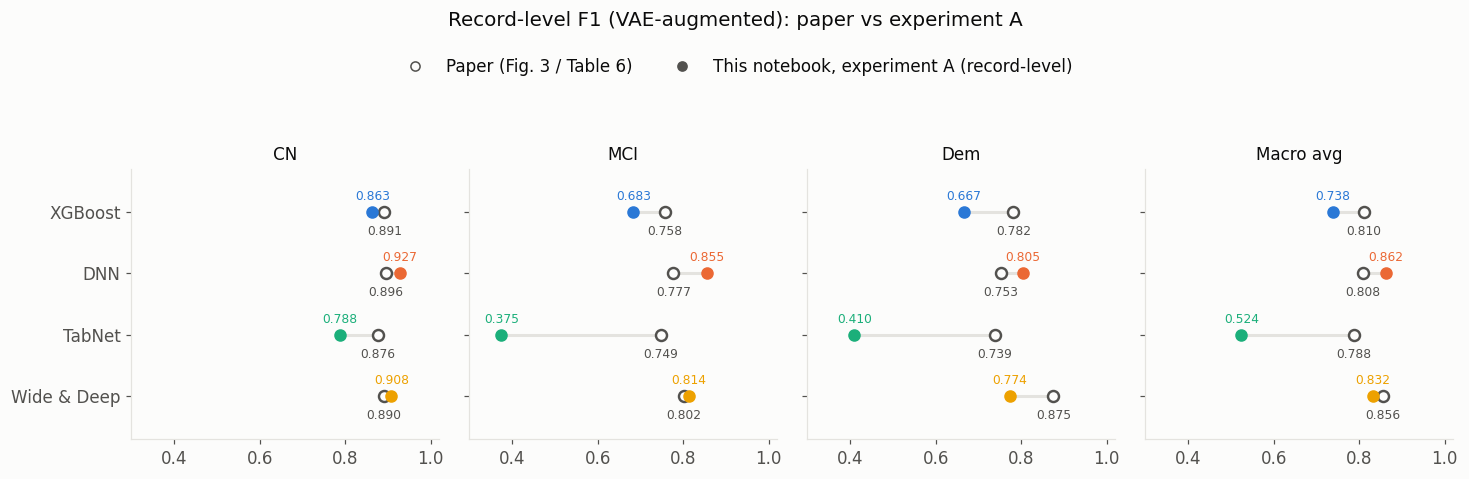

In [ ]:
# ── 그림 1 — 논문 보고값 vs 실험 A (기록 단위 F1, VAE 증강) ──────────────────
if A_df is None:
    print("실험 A 결과가 없어 그림 1을 건너뛴다.")
else:
    CLASSES = ["CN", "MCI", "Dem", "Avg"]
    _a_vae = A_df[A_df["augmentation"] == "vae"].set_index("model")

    def _ours_f1(m, cls):
        if m not in _a_vae.index:
            return None
        row = _a_vae.loc[m]
        return float(row["record_macro_f1"] if cls == "Avg" else row[f"record_{cls}_f1"])

    fig, axes = plt.subplots(1, len(CLASSES), figsize=(13.5, 3.6), sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASSES):
        for i, m in enumerate(MODELS):
            yy = len(MODELS) - 1 - i
            pv, ov = PAPER_F1_VAE[m][cls], _ours_f1(m, cls)
            if ov is not None:
                ax.plot([pv, ov], [yy, yy], color=C_GRID, lw=2, zorder=1)
                ax.scatter([ov], [yy], s=52, color=MODEL_COLOR[m], zorder=3)
                ax.annotate(f"{ov:.3f}", (ov, yy), xytext=(0, 8),
                            textcoords="offset points", ha="center", fontsize=8,
                            color=MODEL_COLOR[m])
            ax.scatter([pv], [yy], s=52, facecolor=C_SURFACE, edgecolor=C_PAPER,
                       linewidth=1.6, zorder=2)
            ax.annotate(f"{pv:.3f}", (pv, yy), xytext=(0, -15),
                        textcoords="offset points", ha="center", fontsize=8,
                        color=C_PAPER)
        ax.set_title({"Avg": "Macro avg"}.get(cls, cls), fontsize=11)
        ax.set_ylim(-0.7, len(MODELS) - 0.3)
        ax.set_xlim(0.3, 1.02)
        ax.set_yticks(range(len(MODELS)))
        ax.set_yticklabels([MODEL_LABEL[m] for m in MODELS[::-1]])
        ax.grid(axis="x")
        ax.grid(False, axis="y")
    _handles = [
        plt.Line2D([], [], marker="o", ls="", mfc=C_SURFACE, mec=C_PAPER,
                   label="Paper (Fig. 3 / Table 6)"),
        plt.Line2D([], [], marker="o", ls="", color=C_TEXT2,
                   label="This notebook, experiment A (record-level)"),
    ]
    fig.legend(handles=_handles, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.12))
    fig.suptitle("Record-level F1 (VAE-augmented): paper vs experiment A",
                 y=1.2, fontsize=13)
    fig.tight_layout()
    plt.show()


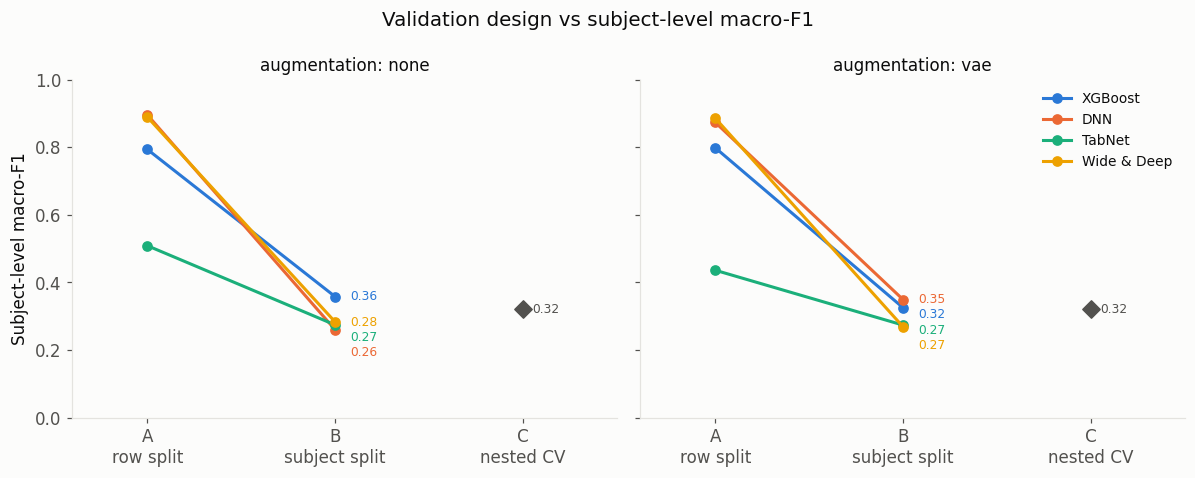

A는 행 단위 분할이라 같은 피험자가 train·test에 함께 있다 — A의 피험자
집계값은 그 누수를 포함한다. C는 fold마다 조합이 새로 선택되므로 모델별
곡선 대신 pooled 한 점(회색 마름모)으로 표시한다.


In [ ]:
# ── 그림 2 — 검증 설계에 따른 피험자 단위 macro-F1 (A → B → C) ───────────────
if A_df is None and B_pool is None and C_pool is None:
    print("그릴 결과가 없다.")
else:
    AUGS = ["none", "vae"]
    _xpos = {"A": 0, "B": 1, "C": 2}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
    for ax, aug in zip(axes, AUGS):
        _endlabels = []
        for m in MODELS:
            xs, ys = [], []
            if A_df is not None:
                row = A_df[(A_df["model"] == m) & (A_df["augmentation"] == aug)]
                if len(row):
                    xs.append(_xpos["A"])
                    ys.append(float(row["subject_macro_f1"].iloc[0]))
            if B_pool is not None and f"{m}|{aug}" in B_pool:
                xs.append(_xpos["B"])
                ys.append(float(B_pool[f"{m}|{aug}"]["macro_f1"]))
            if xs:
                ax.plot(xs, ys, marker="o", ms=6, lw=2, color=MODEL_COLOR[m],
                        label=MODEL_LABEL[m])
                _endlabels.append((xs[-1], ys[-1], f"{ys[-1]:.2f}", MODEL_COLOR[m]))
        _endlabels.sort(key=lambda t: t[1], reverse=True)
        _prev = None
        for _lx, _ly, _txt, _lc in _endlabels:  # 겹치면 세로 간격을 벌린다
            _yy = _ly if _prev is None else min(_ly, _prev - 0.045)
            ax.text(_lx + 0.08, _yy, _txt, va="center", fontsize=8, color=_lc)
            _prev = _yy
        if C_pool is not None:
            ax.scatter([_xpos["C"]], [C_pool["macro_f1"]], marker="D", s=64,
                       color=C_PAPER, zorder=3)
            ax.annotate(f"{C_pool['macro_f1']:.2f}",
                        (_xpos["C"], C_pool["macro_f1"]), xytext=(6, 0),
                        textcoords="offset points", va="center", fontsize=8,
                        color=C_PAPER)
        ax.set_xticks(list(_xpos.values()))
        ax.set_xticklabels(["A\nrow split", "B\nsubject split", "C\nnested CV"])
        ax.set_xlim(-0.4, 2.5)
        ax.set_ylim(0, 1)
        ax.set_title(f"augmentation: {aug}", fontsize=11)
        ax.grid(axis="y")
        ax.grid(False, axis="x")
    axes[0].set_ylabel("Subject-level macro-F1")
    axes[1].legend(loc="upper right", frameon=False, fontsize=9)
    fig.suptitle("Validation design vs subject-level macro-F1", fontsize=13)
    fig.tight_layout()
    plt.show()
    print("A는 행 단위 분할이라 같은 피험자가 train·test에 함께 있다 — A의 피험자")
    print("집계값은 그 누수를 포함한다. C는 fold마다 조합이 새로 선택되므로 모델별")
    print("곡선 대신 pooled 한 점(회색 마름모)으로 표시한다.")


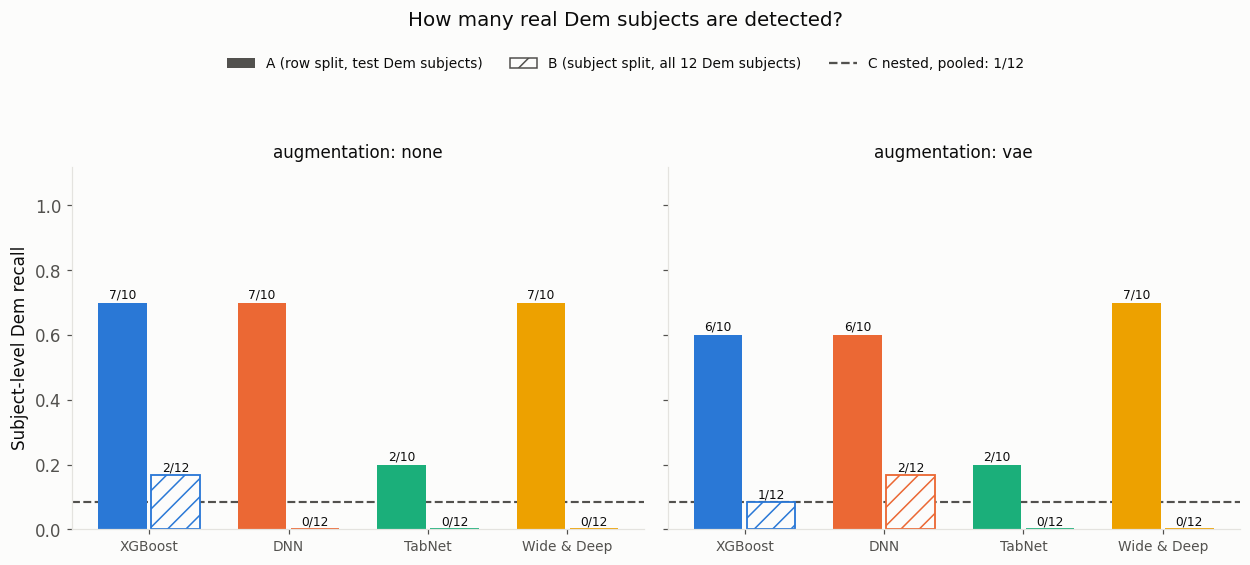

막대 위 숫자 = 탐지한 Dem 피험자 수 / 평가에 포함된 실제 Dem 피험자 수.
주의: A는 test에 등장한 Dem 피험자만 분모가 되고, B·C는 3-fold를 합쳐
12명 전원이 정확히 한 번씩 평가된다 — 분모가 다르다.


In [ ]:
# ── 그림 3 — Dem 피험자 탐지 (피험자 단위 recall, 분모 = 실제 피험자 수) ─────
if A_df is None and B_pool is None:
    print("그릴 결과가 없다.")
else:
    import matplotlib.patches as mpatches
    AUGS = ["none", "vae"]
    _w = 0.38
    _x = np.arange(len(MODELS))
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
    for ax, aug in zip(axes, AUGS):
        for j, m in enumerate(MODELS):
            if A_df is not None:
                row = A_df[(A_df["model"] == m) & (A_df["augmentation"] == aug)]
                if len(row):
                    r = row.iloc[0]
                    v = float(r["subject_Dem_recall"])
                    ax.bar(j - _w / 2, v, _w * 0.92, color=MODEL_COLOR[m], zorder=2)
                    ax.annotate(f"{int(r['subject_n_Dem_correct'])}/{int(r['subject_n_Dem'])}",
                                (j - _w / 2, v), xytext=(0, 3),
                                textcoords="offset points", ha="center", fontsize=8)
            if B_pool is not None and f"{m}|{aug}" in B_pool:
                d = B_pool[f"{m}|{aug}"]
                ax.bar(j + _w / 2, d["Dem_recall"], _w * 0.92, facecolor=C_SURFACE,
                       edgecolor=MODEL_COLOR[m], hatch="//", linewidth=1.2, zorder=2)
                ax.annotate(f"{int(d['n_Dem_correct'])}/{int(d['n_Dem'])}",
                            (j + _w / 2, d["Dem_recall"]), xytext=(0, 3),
                            textcoords="offset points", ha="center", fontsize=8)
        if C_pool is not None:
            ax.axhline(C_pool["Dem_recall"], color=C_PAPER, lw=1.4, ls="--", zorder=1)
        ax.set_xticks(_x)
        ax.set_xticklabels([MODEL_LABEL[m] for m in MODELS], fontsize=9)
        ax.set_ylim(0, 1.12)
        ax.set_title(f"augmentation: {aug}", fontsize=11)
        ax.grid(axis="y")
        ax.grid(False, axis="x")
    axes[0].set_ylabel("Subject-level Dem recall")
    _handles = [
        mpatches.Patch(facecolor=C_TEXT2, label="A (row split, test Dem subjects)"),
        mpatches.Patch(facecolor=C_SURFACE, edgecolor=C_TEXT2, hatch="//",
                       label="B (subject split, all 12 Dem subjects)"),
    ]
    if C_pool is not None:
        _handles.append(plt.Line2D([], [], color=C_PAPER, ls="--",
                                   label=f"C nested, pooled: "
                                         f"{int(C_pool['n_Dem_correct'])}/{int(C_pool['n_Dem'])}"))
    fig.legend(handles=_handles, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.09), fontsize=9)
    fig.suptitle("How many real Dem subjects are detected?", y=1.16, fontsize=13)
    fig.tight_layout()
    plt.show()
    print("막대 위 숫자 = 탐지한 Dem 피험자 수 / 평가에 포함된 실제 Dem 피험자 수.")
    print("주의: A는 test에 등장한 Dem 피험자만 분모가 되고, B·C는 3-fold를 합쳐")
    print("12명 전원이 정확히 한 번씩 평가된다 — 분모가 다르다.")


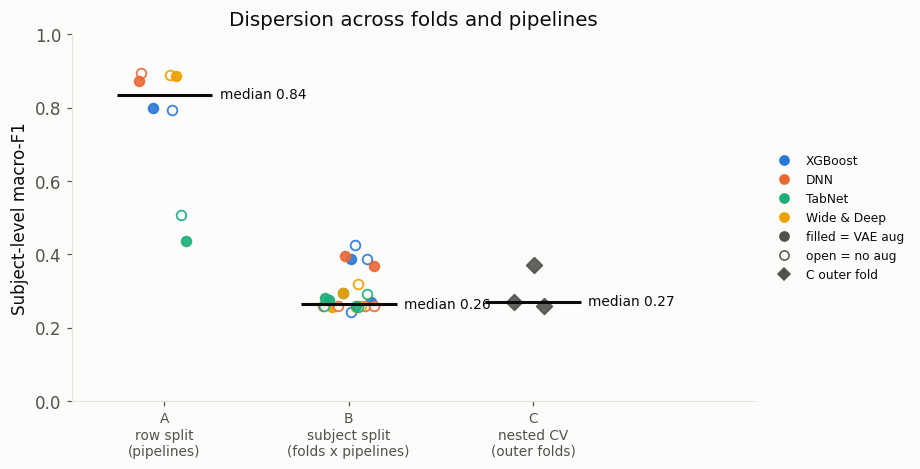

In [ ]:
# ── 그림 4 — fold·파이프라인 간 분산 (피험자 단위 macro-F1) ──────────────────
_cols = []
if A_df is not None:
    _cols.append(("A\nrow split\n(pipelines)", [
        (float(r["subject_macro_f1"]), MODEL_COLOR.get(r["model"], C_PAPER),
         r["augmentation"] == "vae", False) for _, r in A_df.iterrows()]))
if B_fold is not None:
    _cols.append(("B\nsubject split\n(folds x pipelines)", [
        (float(r["subject_macro_f1"]), MODEL_COLOR.get(r["model"], C_PAPER),
         r["augmentation"] == "vae", False) for _, r in B_fold.iterrows()]))
if C_fold is not None:
    _cols.append(("C\nnested CV\n(outer folds)", [
        (float(r["subject_macro_f1"]), C_PAPER, True, True)
        for _, r in C_fold.iterrows()]))

if not _cols:
    print("그릴 결과가 없다.")
else:
    _rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(8.5, 4.4))
    for xc, (_label, _pts) in enumerate(_cols):
        for v, c, filled, diamond in _pts:
            ax.scatter([xc + _rng.uniform(-0.14, 0.14)], [v],
                       s=52 if diamond else 40, marker="D" if diamond else "o",
                       facecolor=c if filled else C_SURFACE, edgecolor=c,
                       linewidth=1.2, zorder=2, alpha=0.9)
        _median = float(np.median([v for v, *_ in _pts]))
        ax.hlines(_median, xc - 0.26, xc + 0.26, color=C_TEXT, lw=2, zorder=3)
        ax.annotate(f"median {_median:.2f}", (xc + 0.3, _median), va="center",
                    fontsize=9, color=C_TEXT)
    ax.set_xticks(range(len(_cols)))
    ax.set_xticklabels([lab for lab, _ in _cols], fontsize=9)
    ax.set_xlim(-0.5, len(_cols) - 0.5 + 0.7)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Subject-level macro-F1")
    ax.grid(axis="y")
    ax.grid(False, axis="x")
    _handles = [plt.Line2D([], [], marker="o", ls="", color=MODEL_COLOR[m],
                           label=MODEL_LABEL[m]) for m in MODELS]
    _handles += [
        plt.Line2D([], [], marker="o", ls="", color=C_TEXT2, label="filled = VAE aug"),
        plt.Line2D([], [], marker="o", ls="", mfc=C_SURFACE, mec=C_TEXT2,
                   label="open = no aug"),
        plt.Line2D([], [], marker="D", ls="", color=C_PAPER, label="C outer fold"),
    ]
    ax.legend(handles=_handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=8)
    ax.set_title("Dispersion across folds and pipelines", fontsize=13)
    fig.tight_layout()
    plt.show()


## 결과 해석 시 반드시 지킬 것

> Dem 클래스는 **독립 피험자 12명**에서 유래한다. 합성 Dem 행은 train fold의 실제
> Dem 기록 분포에서 생성된 것이며 **새로운 피험자가 아니다.** 피험자 단위 지표의
> 분모는 항상 실제 피험자 수다.

- **A와 B·C의 수치를 같은 지표처럼 비교하지 마라.** A는 행 단위 분할(같은 피험자가
  train·test에 중복)이고 전처리도 전체 데이터에 적합했다. B·C만이 "새 피험자에 대한
  일반화"를 측정한다.
- Dem 12명 기준의 신뢰구간은 매우 넓다 (`*_pooled_subject_metrics.json`의
  `macro_f1_ci`·`dem_recall_ci`). 점추정만 인용하지 마라.
- `QUICK_TEST = True`로 얻은 수치는 배선 확인용이다 — 절대 인용하지 마라.
- 이 노트북은 저장소의 기존 재현 파이프라인
  (`SangHyo/Reproduction/reproduction_lee_lee_2025_vae`)과 **코드를 공유하지 않는
  독립 구현**이다. 같은 설계 원칙(피험자 누수 통제·합성행 규칙)을 따르지만
  세부 구현이 달라 수치가 파이프라인 산출물과 다를 수 있다.
